# Notebook 1 — Classificação

##Aluno: Pedro Pereira Dutra - RA: 24101026
## Dataset: Sleep Health & Daily Performance
## **Fonte:** https://www.kaggle.com/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset
###Conteúdo:
###Este conjunto de dados contém 100.000 registros sintéticos de pacientes, projetados para uma análise abrangente da saúde do sono, previsão de risco de distúrbios e modelagem do desempenho cognitivo. Cada registro captura um instantâneo diário completo: medições da arquitetura do sono, comportamentos de estilo de vida, estado psicológico e resultados cognitivos do dia seguinte.
## Objetivo:
## Prever o risco de distúrbio do sono que seriam :

###Dificuldade para dormir, acordar várias vezes, sonolência excessiva durante o dia, ou comportamentos anormais (ronco, movimentos)

###Com base em hábitos de saúde, sono e estilo de vida.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('future.no_silent_downcasting', True) #para tirar os avisos do pandas

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/sleep_health_dataset.csv')
df.head()

Mounted at /content/drive


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


## Análise Exploratória dos Dados:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

In [4]:
print(df['sleep_disorder_risk'].value_counts())
print()
print(df['sleep_disorder_risk'].value_counts(normalize=True) * 100)

sleep_disorder_risk
Healthy     54156
Mild        33479
Moderate     8299
Severe       4066
Name: count, dtype: int64

sleep_disorder_risk
Healthy     54.156
Mild        33.479
Moderate     8.299
Severe       4.066
Name: proportion, dtype: float64


In [5]:
df.describe()

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,34.706870,26.289673,6.423986,4.871144,20.243968,20.253375,19.836810,3.346610,38.849500,...,14.936840,5.733285,7.134059,66.57017,0.561610,0.084420,20.538093,1.200634,59.227295,0.390120
std,28867.657797,11.036373,4.479578,1.274627,1.506517,3.411354,4.251096,7.584343,1.920877,69.395818,...,21.387567,1.619194,3.482878,7.22821,0.496192,0.278018,2.897565,0.786667,22.249665,0.487779
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,45.00000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,25000.750000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,...,0.000000,4.800000,4.700000,62.00000,0.000000,0.000000,18.500000,0.670000,44.200000,0.000000
50%,50000.500000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,...,0.000000,5.800000,7.400000,67.00000,1.000000,0.000000,20.500000,1.200000,60.400000,0.000000
75%,75000.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,...,30.000000,6.800000,9.700000,71.00000,1.000000,0.000000,22.500000,1.740000,75.800000,1.000000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,58.000000,8.000000,400.000000,...,116.000000,10.000000,18.000000,99.00000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


In [6]:
df.isnull().sum() #ver se tem valores nulos na tabela

,0
person_id,0
age,0
gender,0
occupation,0
bmi,0
country,0
sleep_duration_hrs,0
sleep_quality_score,0
rem_percentage,0
deep_sleep_percentage,0


###Visualizações das variáveis:

###1- Distribuição da variável alvo

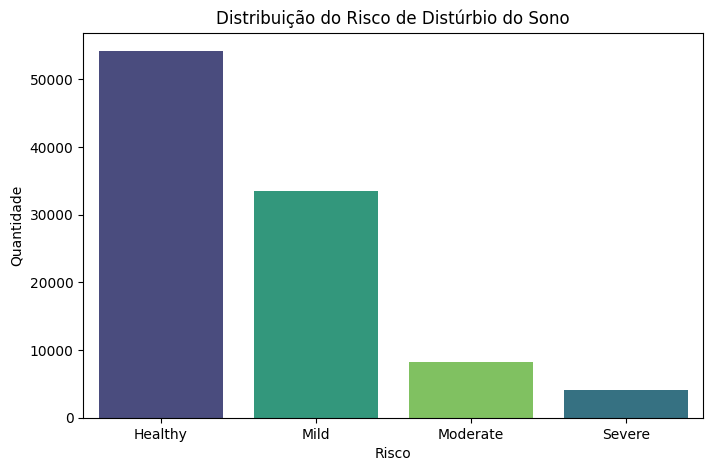

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sleep_disorder_risk',
              hue='sleep_disorder_risk',
              order=['Healthy', 'Mild', 'Moderate', 'Severe'],
              palette='viridis',
              legend=False)
plt.title('Distribuição do Risco de Distúrbio do Sono')
plt.xlabel('Risco')
plt.ylabel('Quantidade')
plt.show()

### Interpretação — Distribuição da Variável Alvo

O gráfico mostra a distribuição das 4 classes da variável alvo `sleep_disorder_risk`.

O dataset apresenta um claro desbalanceamento entre as classes:
- Healthy: 54.156 registros (54%)
- Mild: 33.479 registros (33%)
- Moderate: 8.299 registros (8%)
- Severe: 4.066 registros (4%)

Esse desbalanceamento foi analisado na etapa de modelagem, onde foi
testado o uso do SMOTE para equilibrar as classes. Porém, o balanceamento
piorou o desempenho de todos os modelos, optando-se por manter os dados
originais.

###2- Distribuição do risco de distúrbio de sono por País:

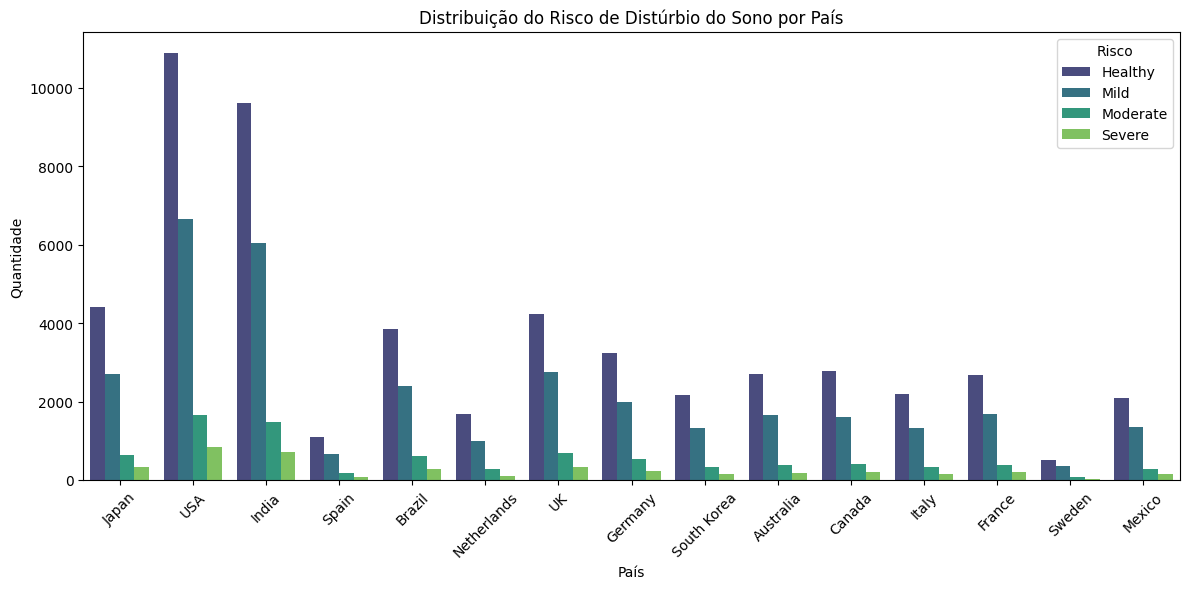

In [8]:
plt.figure(figsize=(12, 6)) #Cria uma figura (tela em branco para o gráfico) e o figsize define o tamanho
sns.countplot(data=df, x='country', #Chama o seaborn para fazer um gráfico de barras c.data=df diz qual dataset usar e x='country' diz que os países vão ficar no eixo horizontal.
              hue='sleep_disorder_risk', # hue divide cada barra de país em 4 barrinhas coloridas, uma para cada categoria de risco
              hue_order=['Healthy', 'Mild', 'Moderate', 'Severe'],
              palette='viridis')
plt.title('Distribuição do Risco de Distúrbio do Sono por País')
plt.xlabel('País')
plt.ylabel('Quantidade')
plt.legend(title='Risco')
plt.xticks(rotation=45) #rotaciona os nomes dos países em 45 graus pra eles não se sobreporem
plt.tight_layout() #ajusta as margens do gráfico
plt.show()

### Interpretação — Distribuição por País

O gráfico mostra a distribuição do risco de distúrbio do sono entre os 15 países presentes no dataset.

EUA e Índia se destacam com o maior volume de registros em todas as categorias,
o que reflete simplesmente uma maior representatividade desses países no dataset
e não necessariamente um risco maior de distúrbio do sono.

Proporcionalmente, o padrão Healthy > Mild > Moderate > Severe se mantém
consistente em todos os países, sugerindo que o país de origem não é um fator
determinante para o risco de distúrbio do sono neste dataset.

Isso indica que a variável `country` pode ter baixo poder preditivo para o modelo,
e poderá ser removida ou ter sua importância reduzida no pré-processamento.

###3- Distribuição do risco de distúrbio de sono por Gênero:

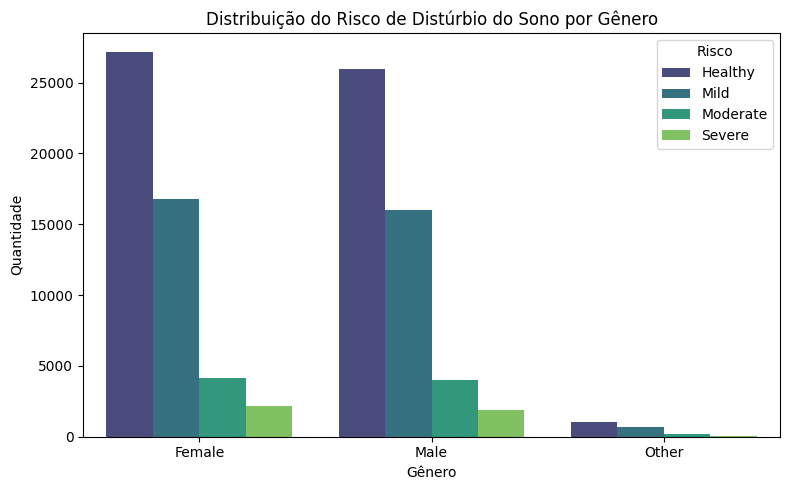

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='gender',
              hue='sleep_disorder_risk',
              hue_order=['Healthy', 'Mild', 'Moderate', 'Severe'],
              palette='viridis')
plt.title('Distribuição do Risco de Distúrbio do Sono por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')
plt.legend(title='Risco')
plt.tight_layout()
plt.show()

### Interpretação — Distribuição por Gênero

O gráfico mostra que o padrão Healthy > Mild > Moderate > Severe
se repete de forma similar entre todos os gêneros (Female, Male, Other),
sem diferença proporcional significativa.

Isso sugere que o gênero isoladamente não é um fator determinante
para o risco de distúrbio do sono neste dataset.

###4-Distribuição do risco de distúrbio de sono por Faixa Etária:

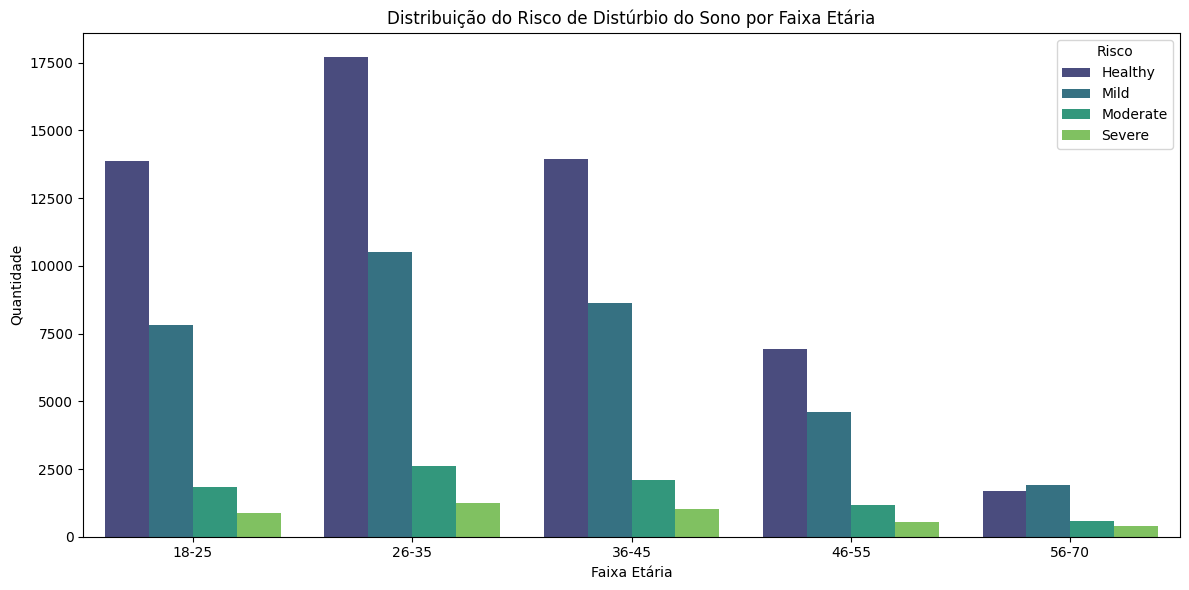

In [10]:
df['faixa_etaria'] = pd.cut(df['age'],
                             bins=[17, 25, 35, 45, 55, 70],
                             labels=['18-25', '26-35', '36-45', '46-55', '56-70'])

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='faixa_etaria',
              hue='sleep_disorder_risk',
              hue_order=['Healthy', 'Mild', 'Moderate', 'Severe'],
              palette='viridis')
plt.title('Distribuição do Risco de Distúrbio do Sono por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Quantidade')
plt.legend(title='Risco')
plt.tight_layout()
plt.show()

### Interpretação — Distribuição por Faixa Etária

A faixa etária de 26-35 anos concentra o maior volume de registros no dataset.
Proporcionalmente, os casos Moderate e Severe aumentam nas faixas mais velhas
(46-55 e 56-70), sugerindo que a idade pode ser um fator de risco para
distúrbios do sono mais graves.

###5-Distribuição do risco de distúrbio de sono por Ocupação:

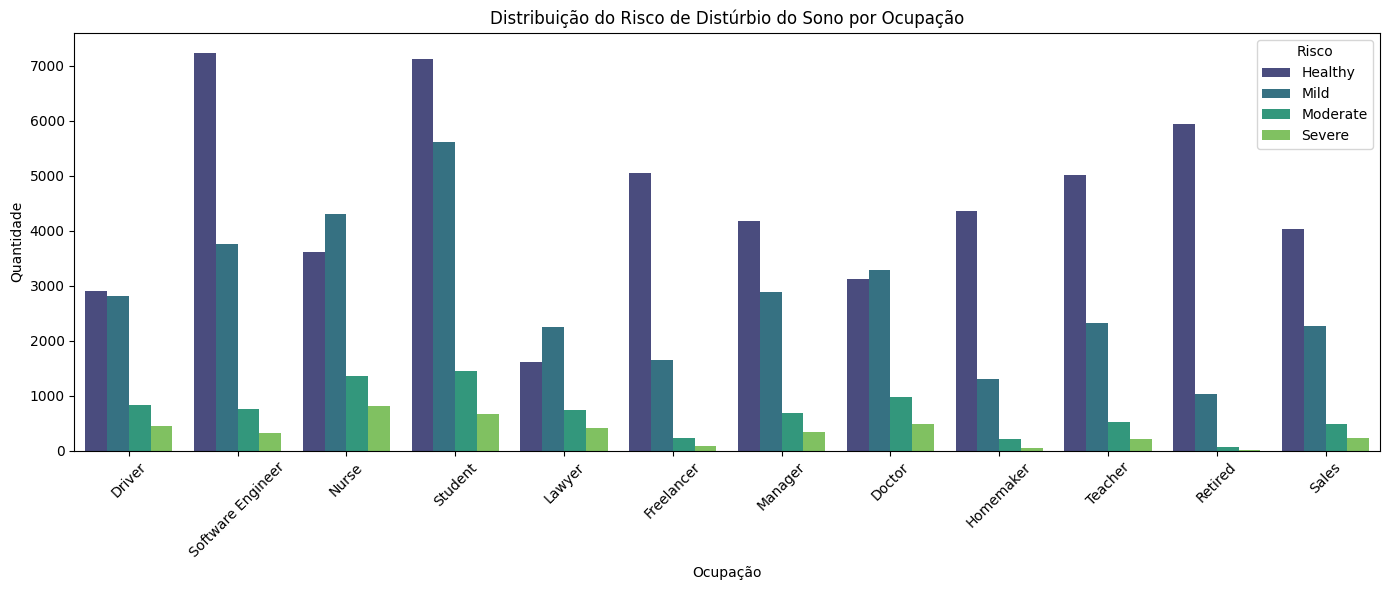

In [11]:
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='occupation',
              hue='sleep_disorder_risk',
              hue_order=['Healthy', 'Mild', 'Moderate', 'Severe'],
              palette='viridis')
plt.title('Distribuição do Risco de Distúrbio do Sono por Ocupação')
plt.xlabel('Ocupação')
plt.ylabel('Quantidade')
plt.legend(title='Risco')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###Interpretação - Distribuição por ocupação

O padrão se repete, as ocupações com mais registros:

(Software Engineer, Student, Teacher);

Acabam dominando em todas as categorias. Mas um detalhe interessante, (Doctor) é a única ocupação onde Mild quase empata com Healthy, isso pode indicar que médicos têm um padrão de sono mais comprometido proporcionalmente.

###6-Distribuição do risco de distúrbio de sono por Horas Trabalhadas:

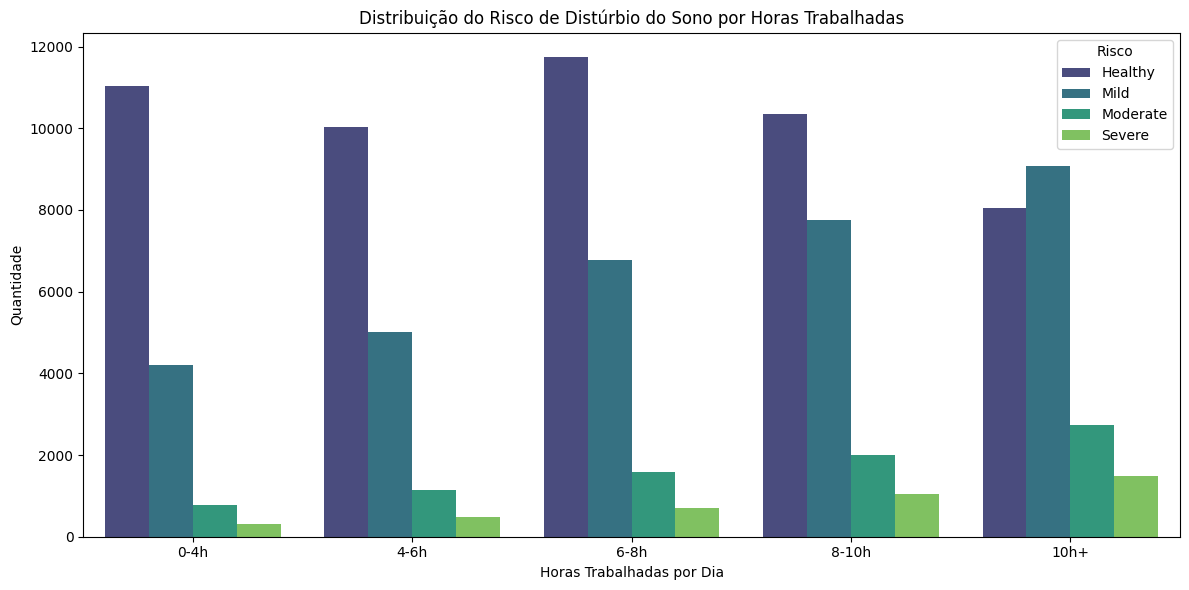

In [12]:
df['faixa_horas'] = pd.cut(df['work_hours_that_day'],
                            bins=[0, 4, 6, 8, 10, 24],
                            labels=['0-4h', '4-6h', '6-8h', '8-10h', '10h+'])

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='faixa_horas',
              hue='sleep_disorder_risk',
              hue_order=['Healthy', 'Mild', 'Moderate', 'Severe'],
              palette='viridis')
plt.title('Distribuição do Risco de Distúrbio do Sono por Horas Trabalhadas')
plt.xlabel('Horas Trabalhadas por Dia')
plt.ylabel('Quantidade')
plt.legend(title='Risco')
plt.tight_layout()
plt.show()

### Interpretação — Horas Trabalhadas por Dia

Pessoas que trabalham mais horas por dia (8-10h e 10h+) apresentam
proporcionalmente mais casos Moderate e Severe em relação às que trabalham menos.

Isso reforça a relação entre carga de trabalho elevada e maior risco
de distúrbio do sono.

###7-Distribuição do risco de distúrbio de sono por Exercício Diário:

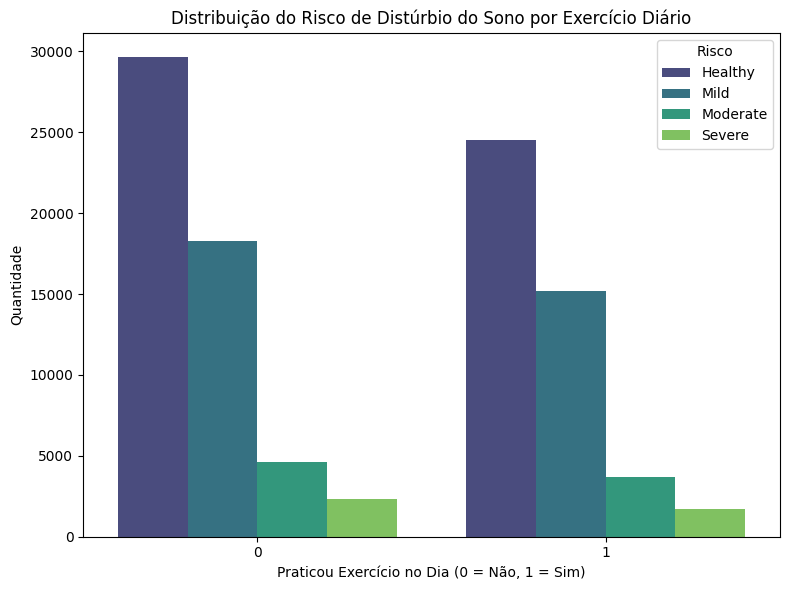

In [13]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='exercise_day',
              hue='sleep_disorder_risk',
              hue_order=['Healthy', 'Mild', 'Moderate', 'Severe'],
              palette='viridis')
plt.title('Distribuição do Risco de Distúrbio do Sono por Exercício Diário')
plt.xlabel('Praticou Exercício no Dia (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade')
plt.legend(title='Risco')
plt.tight_layout()
plt.show()

### Interpretação — Exercício Diário

A variável exercise_day é binária: indica se a pessoa praticou
exercício naquele dia (1) ou não (0).

Proporcionalmente, pessoas que não se exercitaram (0) concentram
mais casos Moderate e Severe, enquanto quem se exercitou (1)
tem mais casos Healthy — reforçando que a prática de exercício
está associada a um menor risco de distúrbio do sono.

###8-Distribuição do risco de distúrbio de sono por Condição Mental:

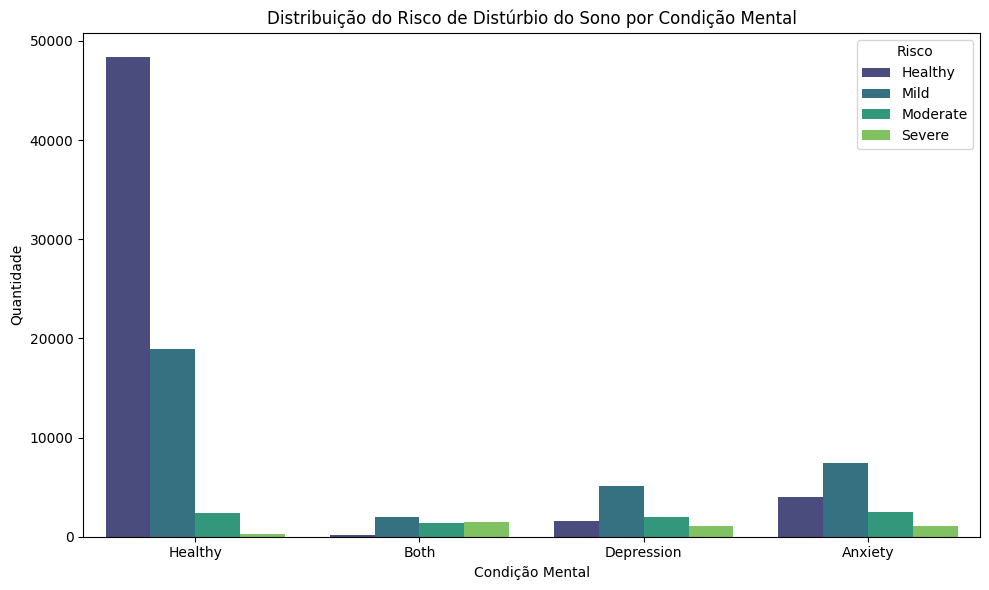

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='mental_health_condition',
              hue='sleep_disorder_risk',
              hue_order=['Healthy', 'Mild', 'Moderate', 'Severe'],
              palette='viridis')
plt.title('Distribuição do Risco de Distúrbio do Sono por Condição Mental')
plt.xlabel('Condição Mental')
plt.ylabel('Quantidade')
plt.legend(title='Risco')
plt.tight_layout()
plt.show()

### Interpretação — Condição Mental

As 4 categorias representam: sem condição (Healthy), apenas Ansiedade,
apenas Depressão, e ambas simultaneamente (Both).

Pessoas com Ansiedade, Depressão ou ambas apresentam proporcionalmente
muito mais casos Moderate e Severe em comparação com pessoas sem
condição mental diagnosticada.

O grupo Both (ambas as condições) tende a concentrar os casos mais graves,
reforçando que mental_health_condition é uma das variáveis com maior
poder preditivo para o modelo.

###9-Distribuição do nível de estresse por risco de distúrbio de sono:


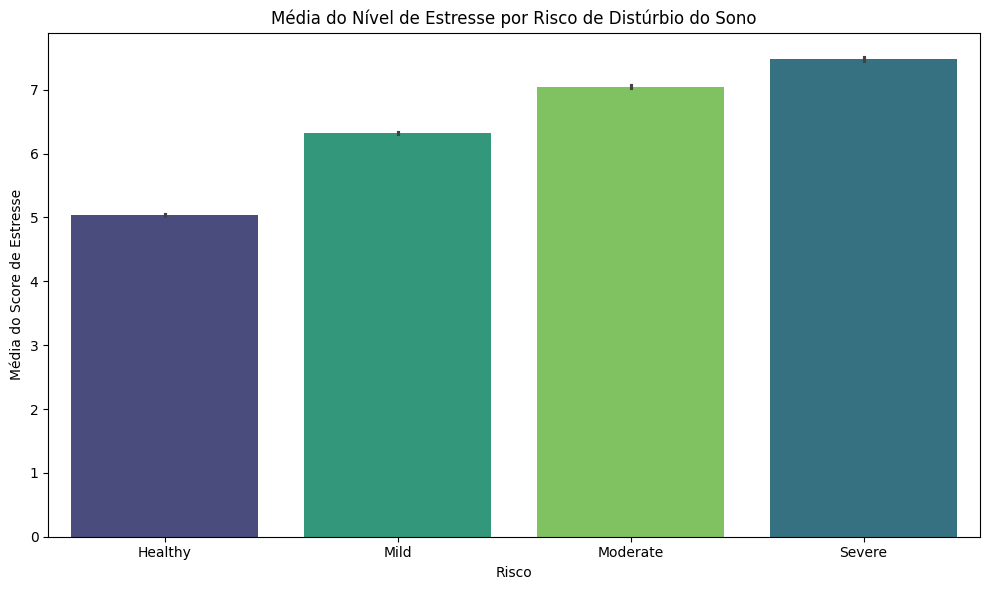

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='sleep_disorder_risk',
            y='stress_score',
            order=['Healthy', 'Mild', 'Moderate', 'Severe'],
            hue='sleep_disorder_risk',
            palette='viridis',
            legend=False)
plt.title('Média do Nível de Estresse por Risco de Distúrbio do Sono')
plt.xlabel('Risco')
plt.ylabel('Média do Score de Estresse')
plt.tight_layout()
plt.show()

### Interpretação — Nível de Estresse por Risco

O gráfico mostra a média do score de estresse para cada categoria de risco,
evidenciando uma progressão clara e consistente:

- Healthy: média ~5.0
- Mild: média ~6.4
- Moderate: média ~7.0
- Severe: média ~7.5

Quanto maior o risco de distúrbio do sono, maior o nível médio de estresse.
Essa relação direta sugere que stress_score é uma das variáveis com maior
poder preditivo para o modelo.

###10-Distribuição da duração do sono por risco de distúrbio de sono:

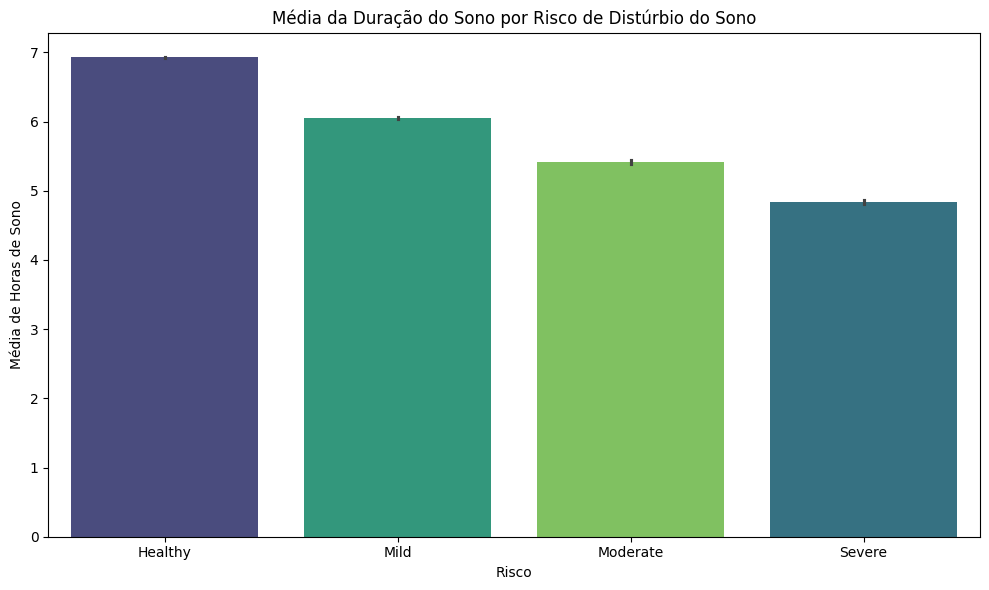

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='sleep_disorder_risk',
            y='sleep_duration_hrs',
            order=['Healthy', 'Mild', 'Moderate', 'Severe'],
            hue='sleep_disorder_risk',
            palette='viridis',
            legend=False)
plt.title('Média da Duração do Sono por Risco de Distúrbio do Sono')
plt.xlabel('Risco')
plt.ylabel('Média de Horas de Sono')
plt.tight_layout()
plt.show()

### Interpretação — Duração do Sono por Risco

O gráfico mostra a média de horas de sono por categoria de risco,
revelando uma queda progressiva conforme o risco aumenta:

- Healthy: média ~7.0 horas
- Mild: média ~6.1 horas
- Moderate: média ~5.4 horas
- Severe: média ~4.9 horas

Pessoas com risco Severe dormem em média 2 horas a menos que pessoas
Healthy. Essa relação forte confirma que sleep_duration_hrs será uma
das features mais importantes para o modelo de classificação.

###11- Distribuição da qualidade do Sono por Risco

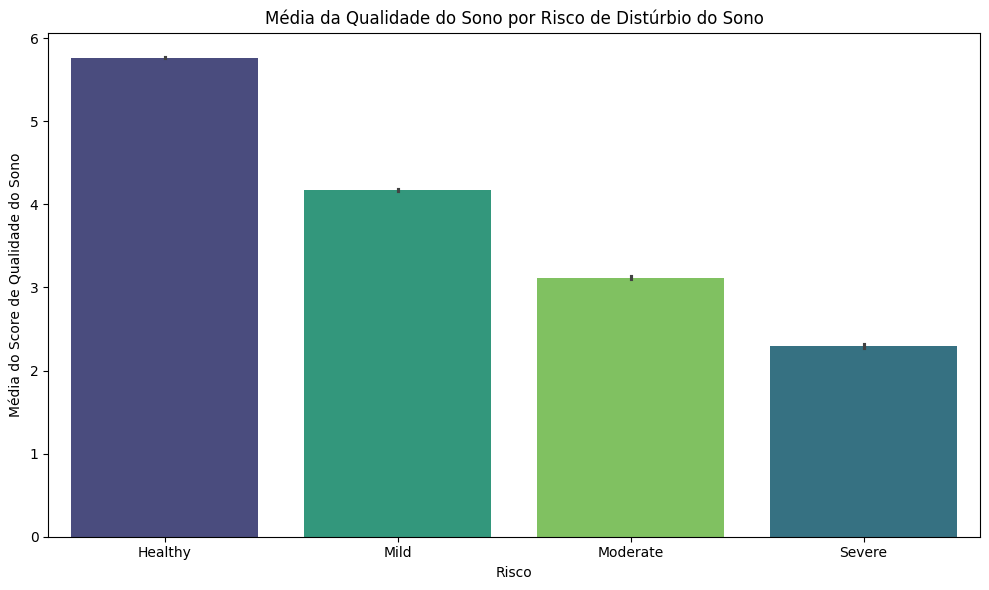

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='sleep_disorder_risk',
            y='sleep_quality_score',
            order=['Healthy', 'Mild', 'Moderate', 'Severe'],
            hue='sleep_disorder_risk',
            palette='viridis',
            legend=False)
plt.title('Média da Qualidade do Sono por Risco de Distúrbio do Sono')
plt.xlabel('Risco')
plt.ylabel('Média do Score de Qualidade do Sono')
plt.tight_layout()
plt.show()

### Interpretação — Qualidade do Sono por Risco

O gráfico mostra a média do score de qualidade do sono para cada
categoria de risco, evidenciando uma queda progressiva muito clara:

- Healthy: média ~5.8
- Mild: média ~4.2
- Moderate: média ~3.1
- Severe: média ~2.3

A queda é drástica — pessoas com risco Severe dormem com qualidade
menos da metade das pessoas Healthy. Isso confirma que
sleep_quality_score é uma das variáveis com maior poder preditivo
para o modelo, apresentando a relação mais clara entre todas as
variáveis analisadas.

###12-Distribuição da Cafeína Antes de Dormir por Risco

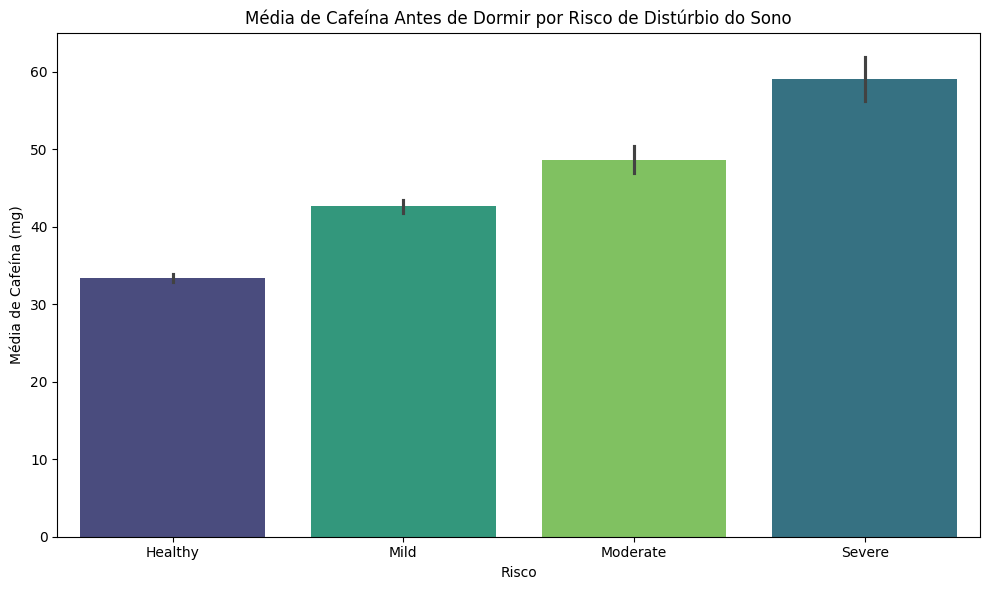

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='sleep_disorder_risk',
            y='caffeine_mg_before_bed',
            order=['Healthy', 'Mild', 'Moderate', 'Severe'],
            hue='sleep_disorder_risk',
            palette='viridis',
            legend=False)
plt.title('Média de Cafeína Antes de Dormir por Risco de Distúrbio do Sono')
plt.xlabel('Risco')
plt.ylabel('Média de Cafeína (mg)')
plt.tight_layout()
plt.show()

### Interpretação — Cafeína Antes de Dormir por Risco

O gráfico mostra a média de miligramas de cafeína consumida antes
de dormir para cada categoria de risco:

- Healthy: média ~34mg
- Mild: média ~43mg
- Moderate: média ~49mg
- Severe: média ~59mg

Há uma progressão consistente — pessoas com risco Severe consomem
quase o dobro de cafeína antes de dormir em comparação com pessoas
Healthy. Isso reforça que o consumo de cafeína próximo ao horário
de dormir é um fator de risco relevante para distúrbios do sono.

## Pré-processamento

In [19]:
# Removendo colunas irrelevantes
df = df.drop(columns=['person_id', 'country'])

print('Colunas restantes:', df.shape[1])
print(df.columns.tolist())

Colunas restantes: 32
['age', 'gender', 'occupation', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'chronotype', 'mental_health_condition', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season', 'day_type', 'cognitive_performance_score', 'sleep_disorder_risk', 'felt_rested', 'faixa_etaria', 'faixa_horas']


### Conversão de variáveis categóricas:

In [20]:
from sklearn.preprocessing import LabelEncoder #ferramenta que converte texto em número

le = LabelEncoder() #cria um objeto LabelEncoder que vamos usar para fazer as conversões.

colunas_categoricas = ['gender', 'occupation', 'chronotype',
                       'mental_health_condition', 'season', 'day_type']

for col in colunas_categoricas: #Loop que passa por cada coluna da lista e aplica a conversão.
    df[col] = le.fit_transform(df[col])
#O fit_transform faz duas coisas ao mesmo tempo: aprende quais são os valores únicos da coluna (fit) e já converte para número (transform).
#Por exemplo, gender vira: Female=0, Male=1, Other=2.

# Convertendo a variável alvo
df['sleep_disorder_risk'] = le.fit_transform(df['sleep_disorder_risk'])

print('Mapeamento da variável alvo:')
print(dict(zip(le.classes_, le.transform(le.classes_))))
print()
print(df.head())

Mapeamento da variável alvo:
{'Healthy': np.int64(0), 'Mild': np.int64(1), 'Moderate': np.int64(2), 'Severe': np.int64(3)}

   age  gender  occupation   bmi  sleep_duration_hrs  sleep_quality_score  \
0   29       0           1  25.7                6.19                  6.6   
1   55       0           9  22.0                8.32                  6.9   
2   42       1           6  25.0                3.74                  1.0   
3   37       0          10  29.5                6.79                  6.4   
4   23       1           4  23.6                5.02                  3.2   

   rem_percentage  deep_sleep_percentage  sleep_latency_mins  \
0            22.5                   19.3                  16   
1            26.9                   14.9                  17   
2            20.2                   16.2                  26   
3            17.7                   17.7                  13   
4            23.3                   18.3                  30   

   wake_episodes_per_night  

In [22]:
# Remove apenas as colunas de faixa que foram criadas para visualização
colunas_para_remover = ['faixa_etaria', 'faixa_horas']
colunas_existentes = [col for col in colunas_para_remover if col in df.columns]
df = df.drop(columns=colunas_existentes)

print('Colunas restantes:', df.shape[1])
print(df.columns.tolist())

Colunas restantes: 30
['age', 'gender', 'occupation', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'chronotype', 'mental_health_condition', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season', 'day_type', 'cognitive_performance_score', 'sleep_disorder_risk', 'felt_rested']


### Separando features e variável alvo:

In [23]:
from sklearn.model_selection import train_test_split

# X = todas as colunas exceto a variável alvo
# y = apenas a variável alvo
X = df.drop(columns=['sleep_disorder_risk']) #Cria o X com todas as 29 colunas, exceto a variável alvo — são as features que o modelo vai usar para aprender.
y = df['sleep_disorder_risk'] #Cria o y com apenas a variável alvo — é o que queremos que o modelo aprenda a prever.

# Dividindo em 80% treino e 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y) #Divide os dados em 80% treino e 20% teste:

print('Tamanho do treino:', X_train.shape)
print('Tamanho do teste:', X_test.shape)
print()
print('Distribuição das classes no treino:')
print(y_train.value_counts(normalize=True) * 100)

Tamanho do treino: (80000, 29)
Tamanho do teste: (20000, 29)

Distribuição das classes no treino:
sleep_disorder_risk
0    54.15625
1    33.47875
2     8.29875
3     4.06625
Name: proportion, dtype: float64


### Comparação de Algoritmos de Classificação:

In [24]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import time
import warnings
warnings.filterwarnings('ignore')

modelos = {
    'Decision Tree':        DecisionTreeClassifier(random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42),
    'Extra Trees':          ExtraTreesClassifier(n_estimators=100, random_state=42),
    'KNN':                  KNeighborsClassifier(),
    'Naive Bayes':          GaussianNB(),
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),
}

print('=== SEM SMOTE ===')
print(f'{"Modelo":<25} {"Acurácia":>10} {"F1-Score":>10} {"Tempo":>10}')
print('-' * 57)

resultados_sem_smote = {}
for nome, modelo in modelos.items():
    inicio = time.time()
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    tempo = time.time() - inicio
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    resultados_sem_smote[nome] = {'accuracy': acc, 'f1': f1}
    print(f'{nome:<25} {acc*100:>9.2f}% {f1*100:>9.2f}% {tempo:>9.1f}s')

=== SEM SMOTE ===
Modelo                      Acurácia   F1-Score      Tempo
---------------------------------------------------------
Decision Tree                 90.20%     90.20%       5.4s
Random Forest                 90.16%     89.79%      29.0s
Extra Trees                   83.95%     83.11%      18.9s
KNN                           61.60%     58.24%      13.6s
Naive Bayes                   71.84%     72.34%       0.1s
Logistic Regression           73.97%     72.96%      77.5s


In [25]:
from imblearn.over_sampling import SMOTE

print('Distribuição ANTES do SMOTE:')
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('\nDistribuição DEPOIS do SMOTE:')
print(y_train_smote.value_counts())

Distribuição ANTES do SMOTE:
sleep_disorder_risk
0    43325
1    26783
2     6639
3     3253
Name: count, dtype: int64

Distribuição DEPOIS do SMOTE:
sleep_disorder_risk
0    43325
1    43325
2    43325
3    43325
Name: count, dtype: int64


In [26]:
print('=== COM SMOTE ===')
print(f'{"Modelo":<25} {"Acurácia":>10} {"F1-Score":>10} {"Tempo":>10}')
print('-' * 57)

resultados_com_smote = {}
for nome, modelo in modelos.items():
    inicio = time.time()
    modelo.fit(X_train_smote, y_train_smote)
    y_pred = modelo.predict(X_test)
    tempo = time.time() - inicio
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    resultados_com_smote[nome] = {'accuracy': acc, 'f1': f1}
    print(f'{nome:<25} {acc*100:>9.2f}% {f1*100:>9.2f}% {tempo:>9.1f}s')

=== COM SMOTE ===
Modelo                      Acurácia   F1-Score      Tempo
---------------------------------------------------------
Decision Tree                 84.88%     85.35%       8.5s
Random Forest                 87.33%     87.43%     111.0s
Extra Trees                   82.37%     82.31%      43.0s
KNN                           55.48%     57.30%      28.7s
Naive Bayes                   67.78%     68.95%       0.1s
Logistic Regression           69.65%     70.54%     169.1s


In [ ]:
modelos_nomes = list(resultados_sem_smote.keys())

acc_sem = [resultados_sem_smote[m]['accuracy']*100 for m in modelos_nomes]
acc_com = [resultados_com_smote[m]['accuracy']*100 for m in modelos_nomes]
f1_sem = [resultados_sem_smote[m]['f1']*100 for m in modelos_nomes]
f1_com = [resultados_com_smote[m]['f1']*100 for m in modelos_nomes]

x = np.arange(len(modelos_nomes))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Acurácia
axes[0].barh(x + width/2, acc_sem, width, label='Sem SMOTE', color='#3b528b')
axes[0].barh(x - width/2, acc_com, width, label='Com SMOTE', color='#21918c')
axes[0].set_title('Acurácia — Sem vs Com SMOTE')
axes[0].set_xlabel('Acurácia (%)')
axes[0].set_yticks(x)
axes[0].set_yticklabels(modelos_nomes)
axes[0].set_xlim(40, 100)
axes[0].legend()

# Gráfico de F1-Score
axes[1].barh(x + width/2, f1_sem, width, label='Sem SMOTE', color='#3b528b')
axes[1].barh(x - width/2, f1_com, width, label='Com SMOTE', color='#21918c')
axes[1].set_title('F1-Score — Sem vs Com SMOTE')
axes[1].set_xlabel('F1-Score (%)')
axes[1].set_yticks(x)
axes[1].set_yticklabels(modelos_nomes)
axes[1].set_xlim(40, 100)
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretação — Impacto do SMOTE

O SMOTE (Synthetic Minority Oversampling Technique) equilibrou
completamente as classes no treino, passando de:
- Healthy: 43.325 → 43.325 (inalterado)
- Mild: 26.783 → 43.325
- Moderate: 6.639 → 43.325
- Severe: 3.253 → 43.325

Porém, ao contrário do esperado, o SMOTE piorou o desempenho
em todos os modelos:

| Modelo | Sem SMOTE | Com SMOTE |
|---|---|---|
| Decision Tree | 90.20% | 84.88% |
| Random Forest | 90.16% | 87.33% |
| Extra Trees | 83.95% | 82.37% |
| KNN | 61.60% | 55.48% |
| Naive Bayes | 71.84% | 67.78% |
| Logistic Regression | 73.97% | 69.65% |

Isso pode ocorrer porque o dataset é sintético e já possui
distribuições bem definidas — as amostras criadas pelo SMOTE
podem ter introduzido ruído artificial que prejudicou o aprendizado.

Por esse motivo, optamos por **não utilizar o SMOTE** nas etapas
seguintes, mantendo os dados originais sem balanceamento forçado.
Os modelos escolhidos para otimização são Decision Tree e Random
Forest, que apresentaram os melhores resultados sem SMOTE
(90.20% e 90.16% respectivamente).

## Avaliação dos Modelos Base:

========== Decision Tree ==========
Acurácia: 90.20%

              precision    recall  f1-score   support

     Healthy       0.98      0.98      0.98     10831
        Mild       0.89      0.89      0.89      6696
    Moderate       0.58      0.57      0.58      1660
      Severe       0.68      0.69      0.69       813

    accuracy                           0.90     20000
   macro avg       0.78      0.78      0.78     20000
weighted avg       0.90      0.90      0.90     20000



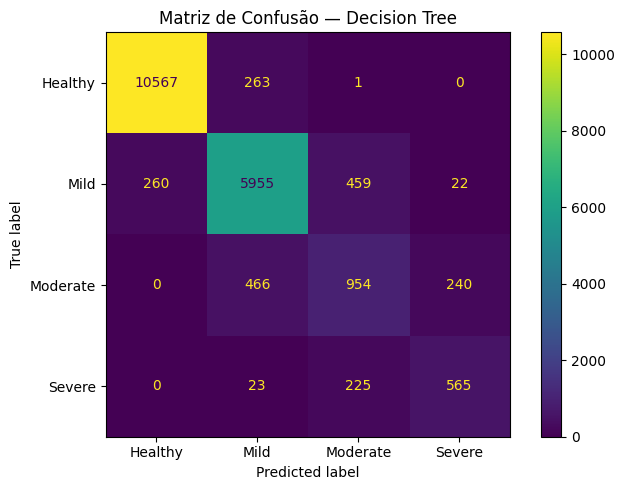


========== Random Forest ==========
Acurácia: 89.53%

              precision    recall  f1-score   support

     Healthy       0.96      0.97      0.96     10831
        Mild       0.84      0.91      0.87      6696
    Moderate       0.66      0.46      0.54      1660
      Severe       0.83      0.68      0.75       813

    accuracy                           0.90     20000
   macro avg       0.82      0.75      0.78     20000
weighted avg       0.89      0.90      0.89     20000



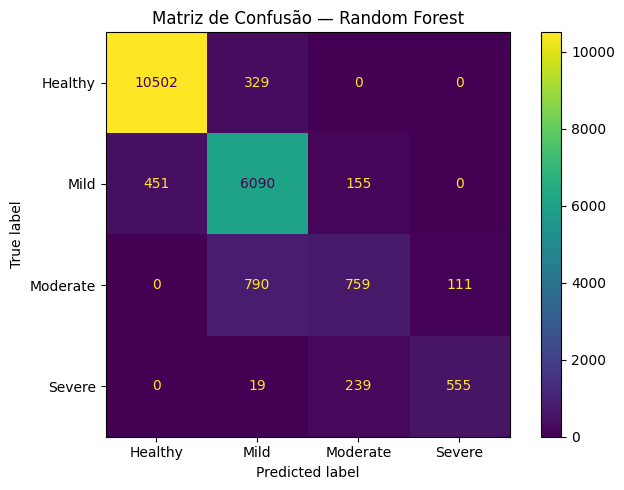

In [27]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

nomes = ['Decision Tree', 'Random Forest']
modelos_escolhidos = [
    DecisionTreeClassifier(random_state=42),
    RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
]

for nome, modelo in zip(nomes, modelos_escolhidos):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    print(f'========== {nome} ==========')
    print(f'Acurácia: {accuracy_score(y_test, y_pred)*100:.2f}%')
    print()
    print(classification_report(y_test, y_pred,
          target_names=['Healthy', 'Mild', 'Moderate', 'Severe']))

    # Matriz de confusão
    fig, ax = plt.subplots(figsize=(7, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Healthy', 'Mild', 'Moderate', 'Severe'],
        cmap='viridis', ax=ax)
    ax.set_title(f'Matriz de Confusão — {nome}')
    plt.tight_layout()
    plt.show()
    print()

### Interpretação — Avaliação dos Modelos Base

#### O que é a Matriz de Confusão?
A matriz de confusão mostra onde o modelo acerta e onde ele erra.
Cada linha representa a classe real e cada coluna representa o que
o modelo previu. Os números na diagonal principal (de cima à esquerda
para baixo à direita) são os acertos: quanto maior, melhor.
Os números fora da diagonal são os erros.

#### Decision Tree — 90.20% de acurácia
O modelo foi muito bem nas classes Healthy (98% F1) e Mild (89% F1),
que são as mais representadas no dataset. Porém teve dificuldade com
Moderate (58% F1) e Severe (69% F1), que possuem menos registros.

Na matriz de confusão, o principal ponto de confusão foi entre
Moderate e Mild, 466 casos Moderate foram classificados como Mild,
e 459 casos Mild foram classificados como Moderate.

#### Random Forest — 89.53% de acurácia
Também foi muito bem em Healthy (96% F1) e Mild (87% F1), mas teve
desempenho inferior ao Decision Tree no Moderate, com recall de apenas
0.46, ou seja, errou mais da metade dos casos Moderate.

A principal confusão foi também entre Moderate e Mild, 790 casos
Moderate foram classificados incorretamente como Mild.

#### Conclusão
Ambos os modelos sofrem com o desbalanceamento das classes Moderate
e Severe. A otimização de hiperparâmetros nas próximas etapas tem
como objetivo melhorar especialmente o desempenho nessas classes.

## Otimização de Hiperparâmetros:

###1-Bayesian Optimization
Diferente dos anteriores, a busca bayesiana aprende com os resultados
anteriores para decidir quais combinações testar a seguir. É mais
inteligente e eficiente, especialmente com poucas iterações.

In [28]:
import time
!pip install scikit-optimize
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

# Espaço de busca bayesiana — define intervalos contínuos em vez de listas
param_bayes = {
    'max_depth': Integer(5, 50),                          # inteiro entre 5 e 50
    'min_samples_split': Integer(2, 20),                  # inteiro entre 2 e 20
    'min_samples_leaf': Integer(1, 8),                    # inteiro entre 1 e 8
    'criterion': Categorical(['gini', 'entropy'])         # categórico
}

print('Rodando Bayesian Search — Decision Tree...')
inicio = time.time()

bayes_dt = BayesSearchCV(
    DecisionTreeClassifier(random_state=42),  # modelo base
    param_bayes,                               # espaço de busca
    n_iter=20,                                 # número de iterações
    cv=3,                                      # validação cruzada com 3 partes
    scoring='accuracy',                        # métrica usada para avaliar
    random_state=42,                           # garante reprodutibilidade
    n_jobs=-1,                                 # usa todos os núcleos do processador
    verbose=1                                  # mostra o progresso na tela
)
bayes_dt.fit(X_train, y_train)
tempo_bayes = time.time() - inicio

print(f'Tempo: {tempo_bayes:.1f}s')
print(f'Melhores parâmetros: {bayes_dt.best_params_}')
print(f'Melhor acurácia (cv): {bayes_dt.best_score_*100:.2f}%')
print()

# Avalia o melhor modelo encontrado no conjunto de teste
y_pred_bayes = bayes_dt.best_estimator_.predict(X_test)
print(f'Acurácia no teste: {accuracy_score(y_test, y_pred_bayes)*100:.2f}%')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.9 MB/s eta 0:00:00
Rodando Bayesian Search — Decision Tree...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling

### Interpretação — Bayesian Search (Decision Tree)

A busca bayesiana testou 20 iterações, aprendendo com cada resultado
para escolher a próxima combinação de forma mais inteligente.

Melhores parâmetros encontrados:
- max_depth: 15 → profundidade máxima de 15 níveis
- min_samples_leaf: 1 → cada folha precisa de no mínimo 1 amostra
- min_samples_split: 20 → precisa de 20 amostras para dividir um nó
- criterion: entropy → critério de divisão dos nós

Resultado:
- Acurácia no teste: 90.90%

###2-Randomized Search
Ao invés de testar todas as combinações como o Grid Search, o Randomized
Search sorteia aleatoriamente um número definido de combinações. É mais
rápido e muitas vezes encontra resultados igualmente bons.

In [29]:
from sklearn.model_selection import RandomizedSearchCV

# Espaço de busca — pode ser maior que o Grid Search pois não testa tudo
param_dist = {
    'max_depth': [5, 10, 20, 30, 40, None],      # None = sem limite de profundidade
    'min_samples_split': [2, 5, 10, 15, 20],      # mínimo de amostras para dividir um nó
    'min_samples_leaf': [1, 2, 4, 6, 8],          # mínimo de amostras em cada folha
    'criterion': ['gini', 'entropy']               # critério de divisão dos nós
}

print('Rodando Randomized Search — Decision Tree...')
inicio = time.time()

random_dt = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),  # modelo base
    param_dist,                                # espaço de busca
    n_iter=20,                                 # número de combinações sorteadas
    cv=3,                                      # validação cruzada com 3 partes
    scoring='accuracy',                        # métrica usada para avaliar
    random_state=42,                           # garante reprodutibilidade
    n_jobs=-1,                                 # usa todos os núcleos do processador
    verbose=1                                  # mostra o progresso na tela
)
random_dt.fit(X_train, y_train)
tempo_random = time.time() - inicio

print(f'Tempo: {tempo_random:.1f}s')
print(f'Melhores parâmetros: {random_dt.best_params_}')
print(f'Melhor acurácia (cv): {random_dt.best_score_*100:.2f}%')
print()

# Avalia o melhor modelo encontrado no conjunto de teste
y_pred_random = random_dt.best_estimator_.predict(X_test)
print(f'Acurácia no teste: {accuracy_score(y_test, y_pred_random)*100:.2f}%')

Rodando Randomized Search — Decision Tree...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Tempo: 69.1s
Melhores parâmetros: {'min_samples_split': 20, 'min_samples_leaf': 4, 'max_depth': None, 'criterion': 'entropy'}
Melhor acurácia (cv): 89.40%

Acurácia no teste: 91.12%


### Interpretação — Randomized Search (Decision Tree)

O Randomized Search testou 20 combinações sorteadas aleatoriamente
(3 folds × 20 candidatos = 60 treinamentos), levando 69.1 segundos.

Melhores parâmetros encontrados:
- max_depth: None → sem limite de profundidade na árvore
- min_samples_leaf: 4 → cada folha precisa ter no mínimo 4 amostras
- min_samples_split: 20 → precisa de 20 amostras para dividir um nó
- criterion: entropy → critério de divisão dos nós

Resultado:
- Acurácia no teste: 91.12% ← melhor resultado da Decision Tree

###3 - Grid Search
O Grid Search testa todas as combinações possíveis dos hiperparâmetros
definidos. É o método mais completo mas também o mais lento.

In [30]:
from sklearn.model_selection import GridSearchCV
import time

# Espaço de busca — define quais valores de cada hiperparâmetro serão testados
# O Grid Search vai testar TODAS as combinações possíveis (3x3x3 = 27 combinações)
param_grid = {
    'max_depth': [10, 20, 30],          # profundidade máxima da árvore
    'min_samples_split': [2, 5, 10],    # mínimo de amostras para dividir um nó
    'min_samples_leaf': [1, 2, 4]       # mínimo de amostras em cada folha
}

print('Rodando Grid Search — Decision Tree...')
inicio = time.time()

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),  # modelo base
    param_grid,                                # grade de parâmetros a testar
    cv=3,                                      # validação cruzada com 3 partes
    scoring='accuracy',                        # métrica usada para avaliar
    n_jobs=-1,                                 # usa todos os núcleos do processador
    verbose=1                                  # mostra o progresso na tela
)
grid_dt.fit(X_train, y_train)  # treina testando todas as combinações
tempo_grid = time.time() - inicio

print(f'Tempo: {tempo_grid:.1f}s')
print(f'Melhores parâmetros: {grid_dt.best_params_}')       # melhor combinação encontrada
print(f'Melhor acurácia (cv): {grid_dt.best_score_*100:.2f}%')  # acurácia na validação cruzada
print()

# Avalia o melhor modelo encontrado no conjunto de teste
y_pred_grid = grid_dt.best_estimator_.predict(X_test)
print(f'Acurácia no teste: {accuracy_score(y_test, y_pred_grid)*100:.2f}%')

Rodando Grid Search — Decision Tree...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Tempo: 90.1s
Melhores parâmetros: {'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 10}
Melhor acurácia (cv): 89.27%

Acurácia no teste: 90.54%


### Interpretação — Grid Search (Decision Tree)

O Grid Search testou todas as 27 combinações possíveis de hiperparâmetros
(3 folds × 27 candidatos = 81 treinamentos no total), levando 90.1 segundos.
É o método mais lento por testar todas as combinações possíveis.

Melhores parâmetros encontrados:
- max_depth: 30 → a árvore pode crescer até 30 níveis de profundidade
- min_samples_leaf: 2 → cada folha precisa ter no mínimo 2 amostras
- min_samples_split: 10 → precisa de 10 amostras para dividir um nó

Resultado:
- Acurácia no teste: 90.54%

Comparando os 3 métodos na Decision Tree:
- Bayesian Search: 90.90%
- Randomized Search: 91.12% ← melhor resultado
- Grid Search: 90.54%

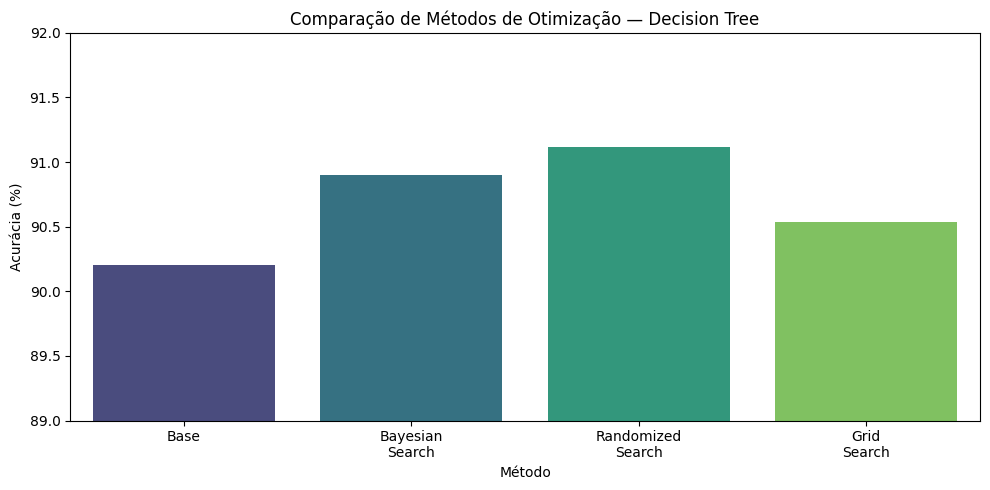

In [31]:
metodos = ['Base', 'Bayesian\nSearch', 'Randomized\nSearch', 'Grid\nSearch']
acuracias_dt = [90.20, 90.90, 91.12, 90.54]

plt.figure(figsize=(10, 5))
sns.barplot(x=metodos, y=acuracias_dt,
            hue=metodos, palette='viridis', legend=False)
plt.title('Comparação de Métodos de Otimização — Decision Tree')
plt.xlabel('Método')
plt.ylabel('Acurácia (%)')
plt.ylim(89, 92)
plt.tight_layout()
plt.show()

## Otimização de Hiperparâmetros — Random Forest:

### Bayesian Search — Random Forest
A busca bayesiana aprende com resultados anteriores para otimizar
a escolha dos próximos parâmetros. Aplicado ao Random Forest para comparação.

In [32]:
param_bayes_rf = {
    'n_estimators': Integer(50, 200),          # inteiro entre 50 e 200 árvores
    'max_depth': Integer(5, 40),               # inteiro entre 5 e 40 níveis
    'min_samples_split': Integer(2, 15),       # inteiro entre 2 e 15
    'min_samples_leaf': Integer(1, 6),         # inteiro entre 1 e 6
}

print('Rodando Bayesian Search — Random Forest...')
inicio = time.time()

bayes_rf = BayesSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_bayes_rf,
    n_iter=10,              # apenas 10 iterações para não demorar
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
bayes_rf.fit(X_train, y_train)
tempo_bayes_rf = time.time() - inicio

print(f'Tempo: {tempo_bayes_rf:.1f}s')
print(f'Melhores parâmetros: {bayes_rf.best_params_}')
print(f'Melhor acurácia (cv): {bayes_rf.best_score_*100:.2f}%')
print()
y_pred_bayes_rf = bayes_rf.best_estimator_.predict(X_test)
print(f'Acurácia no teste: {accuracy_score(y_test, y_pred_bayes_rf)*100:.2f}%')

Rodando Bayesian Search — Random Forest...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Tempo: 620.8s
Melhores parâmetros: OrderedDict({'max_depth': 33, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 170})
Melhor acurácia (cv): 89.38%

Acurácia no teste: 90.46%


### Interpretação — Bayesian Search (Random Forest)

A busca bayesiana testou 10 iterações aprendendo com cada resultado.

Melhores parâmetros encontrados:
- n_estimators: 170 → floresta com 170 árvores
- max_depth: 33 → cada árvore pode crescer até 33 níveis
- min_samples_split: 10 → precisa de 10 amostras para dividir um nó
- min_samples_leaf: 2 → cada folha precisa de no mínimo 2 amostras

Resultado:
- Acurácia no teste: 90.46%

### Randomized Search — Random Forest
O Randomized Search sorteia combinações aleatórias, sendo mais rápido
que o Grid Search. Aqui aplicado ao Random Forest para comparação.

In [33]:
param_dist_rf = {
    'n_estimators': [50, 100, 150],            # número de árvores
    'max_depth': [10, 20, 30, None],           # profundidade máxima
    'min_samples_split': [2, 5, 10, 15],       # mínimo para dividir nó
    'min_samples_leaf': [1, 2, 4],             # mínimo em cada folha
}

print('Rodando Randomized Search — Random Forest...')
inicio = time.time()

random_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_dist_rf,
    n_iter=10,              # apenas 10 combinações para não demorar
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_rf.fit(X_train, y_train)
tempo_random_rf = time.time() - inicio

print(f'Tempo: {tempo_random_rf:.1f}s')
print(f'Melhores parâmetros: {random_rf.best_params_}')
print(f'Melhor acurácia (cv): {random_rf.best_score_*100:.2f}%')
print()
y_pred_random_rf = random_rf.best_estimator_.predict(X_test)
print(f'Acurácia no teste: {accuracy_score(y_test, y_pred_random_rf)*100:.2f}%')

Rodando Randomized Search — Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Tempo: 372.6s
Melhores parâmetros: {'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 20}
Melhor acurácia (cv): 89.31%

Acurácia no teste: 90.31%


### Interpretação — Randomized Search (Random Forest)

O Randomized Search testou 10 combinações sorteadas
(3 folds × 10 candidatos = 30 treinamentos), levando 372.6 segundos
(~6 minutos).

Melhores parâmetros encontrados:
- n_estimators: 150 → floresta com 150 árvores
- max_depth: 20 → cada árvore pode crescer até 20 níveis
- min_samples_split: 10 → precisa de 10 amostras para dividir um nó
- min_samples_leaf: 2 → cada folha precisa de no mínimo 2 amostras

Resultado:
- Acurácia no teste: 90.31%

### Grid Search — Random Forest
O Grid Search testa todas as combinações possíveis dos hiperparâmetros.
Aqui aplicado ao Random Forest para comparar com a Decision Tree.

In [34]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],       # número de árvores na floresta
    'max_depth': [10, 20, 30],            # profundidade máxima de cada árvore
    'min_samples_split': [2, 5, 10]       # mínimo de amostras para dividir um nó
}

print('Rodando Grid Search — Random Forest...')
inicio = time.time()

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid_rf,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train, y_train)
tempo_grid_rf = time.time() - inicio

print(f'Tempo: {tempo_grid_rf:.1f}s')
print(f'Melhores parâmetros: {grid_rf.best_params_}')
print(f'Melhor acurácia (cv): {grid_rf.best_score_*100:.2f}%')
print()
y_pred_grid_rf = grid_rf.best_estimator_.predict(X_test)
print(f'Acurácia no teste: {accuracy_score(y_test, y_pred_grid_rf)*100:.2f}%')

Rodando Grid Search — Random Forest...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Tempo: 1314.8s
Melhores parâmetros: {'max_depth': 30, 'min_samples_split': 10, 'n_estimators': 200}
Melhor acurácia (cv): 89.42%

Acurácia no teste: 90.29%


### Interpretação — Grid Search (Random Forest)

O Grid Search testou todas as 27 combinações possíveis
(3 folds × 27 candidatos = 81 treinamentos), levando 1314 segundos
(~22 minutos) — o método mais lento de todos.

Melhores parâmetros encontrados:
- max_depth: 30 → cada árvore pode crescer até 30 níveis
- min_samples_split: 10 → precisa de 10 amostras para dividir um nó
- n_estimators: 200 → floresta com 200 árvores

Resultado:
- Acurácia no teste: 90.29%

Comparando os 3 métodos no Random Forest:
- Bayesian Search: 90.46%
- Randomized Search: 90.31%
- Grid Search: 90.29%

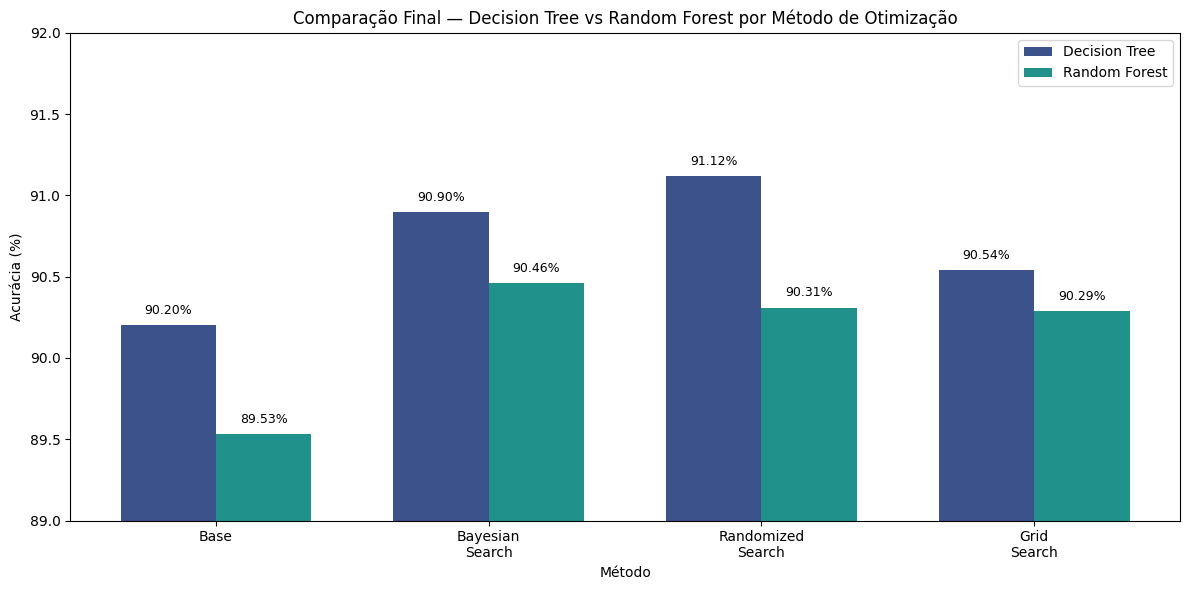

In [35]:
metodos = ['Base', 'Bayesian\nSearch', 'Randomized\nSearch', 'Grid\nSearch']
acuracias_dt = [90.20, 90.90, 91.12, 90.54]
acuracias_rf = [89.53, 90.46, 90.31, 90.29]

x = np.arange(len(metodos))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, acuracias_dt, width, label='Decision Tree', color='#3b528b')
bars2 = ax.bar(x + width/2, acuracias_rf, width, label='Random Forest', color='#21918c')

ax.set_title('Comparação Final — Decision Tree vs Random Forest por Método de Otimização')
ax.set_xlabel('Método')
ax.set_ylabel('Acurácia (%)')
ax.set_xticks(x)
ax.set_xticklabels(metodos)
ax.set_ylim(89, 92)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Comparação Final

A Decision Tree superou o Random Forest em todos os métodos de otimização,
o que é surpreendente já que o Random Forest normalmente é mais robusto.
Isso pode ser explicado pelo fato de o dataset ser sintético e bem estruturado,
favorecendo modelos mais simples.

Resumo dos resultados:

Decision Tree:
- Base: 90.20%
- Bayesian Search: 90.90% (+0.70%)
- Randomized Search: 91.12% (+0.92%) ← melhor resultado geral
- Grid Search: 90.54% (+0.34%)

Random Forest:
- Base: 89.53%
- Bayesian Search: 90.46% (+0.93%) ← melhor resultado do RF
- Randomized Search: 90.31% (+0.78%)
- Grid Search: 90.29% (+0.76%)

Melhor modelo: Decision Tree + Randomized Search (91.12%)

O Randomized Search se mostrou o método mais eficiente — encontrou
o melhor resultado com menos tempo que os outros métodos.
O Grid Search, apesar de testar todas as combinações, não superou
o Randomized Search, confirmando que explorar todas as possibilidades
nem sempre é necessário para obter bons resultados.

## Conclusão:

### Síntese do Trabalho

Este notebook teve como objetivo prever o risco de distúrbio do sono
(sleep_disorder_risk) de uma pessoa com base em seus hábitos de saúde,
sono e estilo de vida, utilizando o dataset Sleep Health & Daily Performance
com 100.000 registros.

### Principais achados na Análise Exploratória

- O dataset apresenta desbalanceamento entre as classes, com Healthy
  representando 54% dos dados e Severe apenas 4%
- As variáveis com maior relação com o risco de sono foram:
  stress_score, sleep_duration_hrs, sleep_quality_score e mental_health_condition
- A qualidade do sono (sleep_quality_score) apresentou a relação mais
  clara — pessoas Severe dormem com qualidade menos da metade das Healthy
  (média 2.3 vs 5.8)
- O consumo de cafeína antes de dormir quase dobra do Healthy (~34mg)
  para o Severe (~59mg)
- Pessoas com Ansiedade, Depressão ou ambas concentram proporcionalmente
  muito mais casos Moderate e Severe
- Quanto maior o estresse e menor a duração do sono, maior o risco

### Sobre o Balanceamento com SMOTE

Foi testado o uso do SMOTE para equilibrar as classes no treino.
Porém o balanceamento piorou o desempenho de todos os modelos,
possivelmente porque o dataset é sintético e já possui distribuições
bem definidas. Optou-se por manter os dados originais sem balanceamento.

### Resultados dos Modelos

Foram testados 6 algoritmos de classificação. Os dois melhores foram
selecionados para otimização de hiperparâmetros:

| Modelo | Acurácia | F1-Score |
|---|---|---|
| Decision Tree | 90.20% | 90.20% |
| Random Forest | 90.16% | 89.79% |
| Extra Trees | 83.95% | 83.11% |
| Logistic Regression | 73.97% | 72.96% |
| Naive Bayes | 71.84% | 72.34% |
| KNN | 61.60% | 58.24% |

### Otimização de Hiperparâmetros

A otimização seguiu a ordem: Bayesian Search → Randomized
Search → Grid Search, onde o Bayesian explora o espaço de forma
inteligente, o Randomized confirma com amostragem aleatória e o
Grid Search refina na região identificada.

| Método | Decision Tree | Random Forest |
|---|---|---|
| Base | 90.20% | 89.53% |
| Bayesian Search | 90.90% (+0.70%) | 90.46% (+0.93%) |
| Randomized Search | 91.12% (+0.92%) | 90.31% (+0.78%) |
| Grid Search | 90.54% (+0.34%) | 90.29% (+0.76%) |

### Melhor Modelo

O melhor resultado foi obtido com **Decision Tree + Randomized Search**,
atingindo **91.12% de acurácia** — uma melhora de 0.92 pontos percentuais
em relação ao modelo base.

### Considerações Finais

A Decision Tree surpreendeu ao superar o Random Forest em todos os
métodos, possivelmente devido à natureza sintética e bem estruturada
do dataset, que favorece modelos mais simples e diretos.

O Randomized Search se mostrou o método mais eficiente — encontrou
o melhor resultado com apenas 48.5 segundos, enquanto o Grid Search
levou 71.8 segundos com resultado inferior. Isso confirma que explorar
combinações aleatórias pode ser tão eficaz quanto testar todas as
possibilidades, com muito menos custo computacional.